In [20]:
%cd ~/code/entityrepresentations

import torch, gc, sys, os, pathlib
import torch.nn as nn
import torch
import numpy as np
from torch.utils.data import DataLoader
from datasets import load_dataset
import transformer_lens as tl 
from transformer_lens import HookedTransformer
from importlib import reload
from tqdm import tqdm
import matplotlib.pyplot as plt

#our own code
import utils
        
IN_GITHUB = os.getenv("GITHUB_ACTIONS") == "true"
# from IPython.display import display
# import ipywidgets as widgets
# # reload(IPython.display)
# reload(widgets)
from LabelExtractor import eval_model, compute_metrics, infer_entities
from processResults import *
reload(sys.modules['LabelExtractor'])
reload(utils)

# from IPython import get_ipython
# ip = get_ipython()
# if not ip.extension_manager.loaded:
#     ip.extension_manager.load('autoreload')
#     %autoreload 2

/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/morand/reimplems/taskVectorsHendel/env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
Using the latest cached version of the module from /home/morand/.cache/huggingface/modules/evaluate_modules/metrics/evaluate-metric--chrf/d244bab9383988714085a8dacc4871986d9f025398581c33d6b2ee22836b4069 (last modified on Thu Jun 27 14:17:21 2024) since it couldn't be found locally at evaluate-metric--chrf, or remotely on the Hugging Face Hub.


/home/morand/code/entityrepresentations


<module 'utils' from '/home/morand/code/entityrepresentations/utils.py'>

## Params

In [21]:
# Load a model (eg GPT-2 Small)
model_name = "bloom-3b" #crashed
model_name = "meta-llama/Meta-Llama-3-8B" # ?
model_name = "gpt2-small" # 117M ok
model_name = "gpt2-xl" # 1.5B ok
model_name = "gpt2-large" # 774M ok
model_name = "mistralai/Mistral-7B-v0.1" # ok JZ a100 8cpus | 
model_name = "gpt2-medium" # 302M ok
model_name = "phi-3" # 3,6B -> OK ?
model_name = "EleutherAI/pythia-6.9b"#? CRASHED
model_name = "EleutherAI/pythia-2.8b"#ok !
model_name = "phi-1_5"  # 1.5B ok
model_name = "EleutherAI/pythia-410m"# ok !
model_name = "EleutherAI/pythia-1b"# ok ! (6Gb)
model_name = "phi-2" # 2,5B ok

dataset_name= "TACRED"
dataset_name= "WebNLG"
dataset_name= "CoNLL2003"

layer = 10

with_context = True
with_context = False

dtype = torch.float16
dtype = torch.float32
dtype = torch.bfloat16

xp_path = pathlib.Path.home() / "experiments_JeanZay"

# load results
xp_path = pathlib.Path.home() / "experiments_JeanZay"
#get all experiments directories
xp_paths= os.listdir(xp_path / "jobs")
jobs_path = xp_path / "jobs" / xp_paths[0]
#get jobs
results = loadResults(jobs_path)

#filter results by model
results = results[(results["model_name"]==model_name) &
                  (results["dataset_name"]==dataset_name) &
                  (results["with_context"]==with_context) ]

print(f"Loaded {len(results)} results")
results.head()

100%|███████████████████████████████████████████████████████████████████████████| 1379/1379 [02:27<00:00,  9.33it/s]


Loaded 66 results


,path,model_name,layer,max_ent_length,epochs,lr,batch_size,with_context,dataset_name,extraction_method,history,Eval,Linear Eval,inference,logs_per_epoch,max_length,version
785,/home/morand/experiments_JeanZay/jobs/labelext...,phi-2,18,20,10,0.05,50,False,CoNLL2003,in_context,"[{'epoch': 0.24835164835164836, 'loss': 1.2602...","{'Partial Match': 0.6717387270365559, 'Exact M...","{'Partial Match': 0.6670996474299499, 'Exact M...",/home/morand/experiments_JeanZay/jobs/labelext...,4.0,200.0,1.0
794,/home/morand/experiments_JeanZay/jobs/labelext...,phi-2,23,20,10,0.05,50,False,CoNLL2003,in_context,"[{'epoch': 0.24835164835164836, 'loss': 1.4726...","{'Partial Match': 0.6782334384858044, 'Exact M...","{'Partial Match': 0.6719242902208202, 'Exact M...",/home/morand/experiments_JeanZay/jobs/labelext...,4.0,200.0,1.0
795,/home/morand/experiments_JeanZay/jobs/labelext...,phi-2,16,20,10,0.05,50,False,CoNLL2003,in_context,"[{'epoch': 0.24835164835164836, 'loss': 1.5022...","{'Partial Match': 0.6670996474299499, 'Exact M...","{'Partial Match': 0.6758211170903693, 'Exact M...",/home/morand/experiments_JeanZay/jobs/labelext...,4.0,200.0,1.0
799,/home/morand/experiments_JeanZay/jobs/labelext...,phi-2,24,20,10,0.05,50,False,CoNLL2003,in_context,"[{'epoch': 0.24835164835164836, 'loss': 1.8139...","{'Partial Match': 0.6769344961959547, 'Exact M...","{'Partial Match': 0.6663573946928929, 'Exact M...",/home/morand/experiments_JeanZay/jobs/labelext...,4.0,200.0,1.0
801,/home/morand/experiments_JeanZay/jobs/labelext...,phi-2,8,20,10,0.05,50,False,CoNLL2003,in_context,"[{'epoch': 0.24835164835164836, 'loss': 1.5745...","{'Partial Match': 0.6813880126182965, 'Exact M...","{'Partial Match': 0.711634811653368, 'Exact Ma...",/home/morand/experiments_JeanZay/jobs/labelext...,4.0,200.0,1.0


## Model Loading

In [22]:
# del model
gc.collect()
torch.cuda.empty_cache()

In [23]:

#check if model variable exists
if not 'model' in locals():
    model = HookedTransformer.from_pretrained(
                                    model_name, 
                                    trust_remote_code = True, 
                                    # low_cpu_mem_usage = True, 
                                    device_map='auto',
                                    move_to_device=False,
                                    fold_ln=False,
                                    fold_value_biases=False,
                                    center_writing_weights=False,
                                    torch_dtype=dtype,
                                    center_unembed=False,
                                    )
    print(model)
    model.eval()

model = model.cuda()
    # dim = model.QK.shape[-1]

Moving model to device:  cuda


## Load taskvec

In [24]:
fileName = get_taskVec(results, model_name, layer=layer, dataset_name=dataset_name, with_context = with_context)

TaskVec = torch.load(fileName)

print("TaskVec loaded from ", fileName)

found 2 jobs for layer 10 of phi-2 without context on CoNLL2003
found ['TaskVec_phi-2_l10_e9.993406593406593.pth', 'LabelExtractor_phi-2_l10_e10.0noContext.pth'] 
TaskVec loaded from  /home/morand/experiments_JeanZay/jobs/labelextractor.learnlabelextractor/e1ceff7cecaf76072a800d9654150b1408aa4ae08de596611ca718140182f3d7/TaskVec_phi-2_l10_e9.993406593406593.pth


## Data

In [25]:
dataset_name = "CoNLL2003"
ds = load_dataset("eriktks/conll2003", trust_remote_code=True)
print("train :", len(ds["train"]))
print("test :", len(ds["test"]))
print("validation :", len(ds["validation"]))

# from utils import CoNLLDataset
max_ent_length = 60
max_length = 300
train_dataset = utils.CoNLLDataset(ds["train"], max_ent_length=max_ent_length,max_length=max_length)
test_dataset = utils.CoNLLDataset(ds["test"], max_ent_length=max_ent_length,max_length=max_length)
val_dataset = utils.CoNLLDataset(ds["validation"], max_ent_length=max_ent_length,max_length=max_length)
val_dataset.data = val_dataset.data[:1000] # limit validation set to 1000 samples

def unique_entities(dataset):
    entities = set()
    entities.update([d["entity"] for d in dataset])
    return [{"entity": ent} for ent in entities]

#ex sample from final dataset
print("train length:", len(train_dataset))
print("test length:", len(test_dataset))

#transform to unique entities
uniq_train_dataset = unique_entities(train_dataset)
uniq_test_dataset = unique_entities(test_dataset)
uniq_val_dataset = unique_entities(val_dataset)

print("\nAfter filtering")
print("train length:", len(train_dataset))
print("test length:", len(test_dataset))
print("validation length:", len(val_dataset))

train_dataset[np.random.randint(len(train_dataset))]

train : 14041
test : 3453
validation : 3250
train length: 22749
test length: 5389

After filtering
train length: 22749
test length: 5389
validation length: 1000


{'entity': 'CAIRO', 'text': 'CAIRO 1996-08-22', 'id': 2444}

# Trained Representation Vectors

## Training

### Training routine

In [26]:
from torch.linalg import vector_norm
def train_reps(
            data:list,
            with_context:bool = False,
            N_trials:int = 40,
            l2_reg = 0.0,
            prepend_bos:bool = True,
            lr:float = 2e-1,
            N_steps:int = 150,
            log_every_N:int = 20,
          ):
    """
    Train `N_trials` representations from gaussian Noise to regenerate `entities` with the model and the given taskVec.
    """
    eos_tok_str = model.tokenizer.eos_token
    replace_hook_name = tl.utils.get_act_name('embed') #pos_embed for gpt2 ... 
    num_reps = len(data)
    dim = TaskVec.shape[-1]
    hist = []

    #instanciate all tensors 
    reps = torch.normal(mean=0, std=1.0, 
                        size=(num_reps*N_trials,dim), 
                        requires_grad=True, 
                        dtype=dtype, 
                        device="cuda")
    b_size = reps.shape[0]
    b_taskVec = TaskVec.repeat(b_size,1).cuda()

    # optimizer
    optim = torch.optim.Adam([reps], lr=lr)
    # optim = torch.optim.SGD([TaskVec], lr=lr)

    gc.collect()
    torch.cuda.empty_cache()

    # print(f"Training reps for entities: {[d['entity'] for d in data]}, with {N_trials} trials")
    entities = []
    for d in data: entities += [d["entity"]] * N_trials
    entities = [ent + eos_tok_str for ent in entities] # take whole label add eos token

    if with_context:
        texts = []
        for d in data: texts += [d["text"]] * N_trials
        prompts = [txt + "_ >" for txt in texts]
        context_toks = model.to_tokens(prompts, prepend_bos=prepend_bos, padding_side="left") 
        entities_toks = model.to_tokens(entities, prepend_bos=False, padding_side="right")
        inputs = torch.cat([context_toks, entities_toks], dim=1)
        rep_idx = context_toks.shape[1] - 2
    else:
        rep_idx = 1 if prepend_bos else 0 
        prompts = ["_ > " + ent for ent in entities]
        inputs = model.to_tokens(prompts, prepend_bos=prepend_bos,)

    rep_idxs = torch.tensor(b_size * [rep_idx])
    taskVec_idxs = torch.tensor(b_size * [rep_idx + 1])
    targets = inputs[:,rep_idx+1:] #don't take the '<eos>', <context>, '_' tokens into account

    # print(prompts)
    # print(f"{'Resuming' if hist else 'Starting'} training TaskVec on {dataset_name} for layer {layer} of {model_name} with{'out' if not with_context else ''} context...")
    for step in range(N_steps):
            
        logits = model.run_with_hooks(
                inputs,
                return_type = "logits",
                fwd_hooks=[
                    (replace_hook_name, utils.get_replace_with_rep_hook(reps, rep_idxs)), # replace '_' by the subject Representation
                    (replace_hook_name, utils.get_replace_with_rep_hook(b_taskVec, taskVec_idxs)) # replace 'called' by TaskVec Representation
                    ]
            ,)

        # LM Loss and optimization # take only the loss on the entity tokens
        loss = model.loss_fn(logits[:, rep_idx+1:,:], targets)
        if l2_reg > 0: loss += l2_reg * vector_norm(reps, ord=2, dim=1).mean()
        loss.backward()
        optim.step()
        optim.zero_grad()
        m_loss = loss.item()
        # scheduler.step()

        hist.append({"step":step, "loss": m_loss, "lr":lr})
        # if step % log_every_N == 0:
            # print(f"Step {step:.1f}, Loss: {m_loss:.5f}")
            # lr = scheduler.get_last_lr()[0]
            #save best taskVec according to test accuracy
            # if hist and acc >= max([h["test accuracy"] for h in hist]):
            #     print(f" {acc:.3f} is the best accuracy so far, saving TaskVec ...")
            #     best_TaskVec[:] = TaskVec[:]
    # print(f"Step {step:.1f}, Loss: {m_loss:.5f}")
    reps = reps.detach().cpu()
    return reps, hist


### Train representations for each entity in the dataset

In [194]:
N = 40 # number of entities to train
num_reps = 3
N_trials = 40
lr = 1e-2
N_steps = 120
log_every_N = 100
prepend_bos = True

dim = model.QK.shape[-1]
dtype = model.W_U.dtype

for param in model.parameters():
    param.requires_grad = False
TaskVec.requires_grad = False
TaskVec = TaskVec.type(dtype)
#get random sample
# random split of whole dataset
train_data = [train_dataset[i] for i in np.random.permutation(len(train_dataset))[:N]]

#keep only unique entities

# load train data by batch of num_reps
for i in (pbar := tqdm(range(0, len(train_data), num_reps))):
    data = train_data[i:i+num_reps]
    # print(data)
    # print(f"\t[{i}/{len(train_data)}] -------------------")
    reps, hist = train_reps( 
                data,
                with_context=False, 
                N_trials=N_trials, 
                prepend_bos=prepend_bos, 
                lr=lr, 
                N_steps=N_steps, 
                # l2_reg=1e-4,
                log_every_N=log_every_N, 
                )
    last_loss = hist[-1]["loss"]
    pbar.set_description(f"LM loss: {last_loss:.3f}")
    
    for j, d in enumerate(data): #TODO Check HERE
        reps_ent = reps[N_trials*j: N_trials*(j+1), :]
        d["all_representations"] = reps_ent
        d["representation"] = reps_ent.mean(dim=0)
        d["hist"] = hist

# 360 x 30 tries = 1h10
#5 = 1min30

LM loss: 0.010: 100%|███████████████████████████████████████████████████████████████| 14/14 [10:29<00:00, 44.94s/it]


In [225]:
ind = np.random.randint(len(train_data))
data = train_data[ind]
print(data["entity"])
print(data["all_representations"].shape)
print(data["representation"].shape)
var = data["all_representations"].float().var(dim=0).mean()
#compute variance of representations
print("variance of representations:", var)


U.S. Defense Logistics Agency
torch.Size([40, 2560])
torch.Size([2560])
variance of representations: tensor(1.0287)


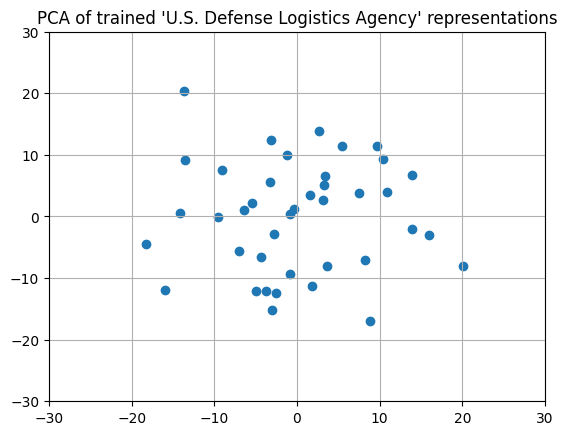

In [228]:
#pca on reps
from sklearn.decomposition import PCA

X = data["all_representations"].float().cpu().numpy()
pca = PCA(n_components=2)
pca.fit(X)
X_pca = pca.transform(X)

plt.title(f"PCA of trained '{data['entity']}' representations")
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlim(-30,30)
plt.ylim(-30,30)
plt.grid()
plt.show()


In [231]:

linear = nn.Linear(5, 1).cuda()
#update weights
linear.weight.data = torch.eye(5).cuda()

print(linear.weight.data)

#copy linear for checkpoint 
checkpoint = linear.state_dict()

# retreive stored weights
linear.weight.data = torch.zeros((5,5)).cuda()
print(linear.weight.data)

#restore checkpoint
linear.load_state_dict(checkpoint)
print(linear.weight.data)



tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]], device='cuda:0')
tensor([[0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0.]], device='cuda:0')
tensor([[1., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 1.]], device='cuda:0')


In [ ]:
# save data 
import pickle
with open(f"train_data_{model_name}_{dataset_name}_layer{layer}.pkl", "wb") as f:
    pickle.dump(train_data, f)

### Check last training curve

Text(0.5, 1.0, 'Loss during training for phi-2 on CoNLL2003 without context')

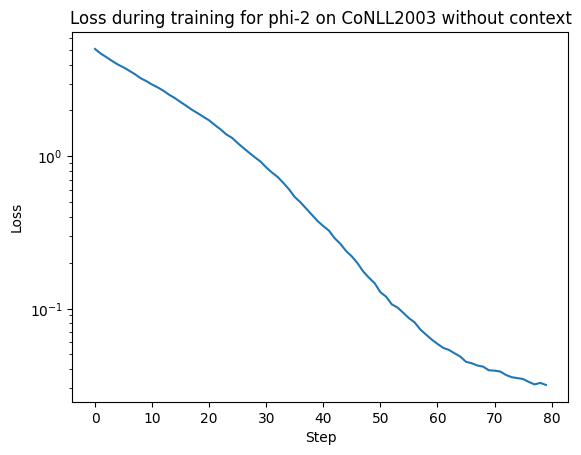

In [193]:
#plot last hist
plt.plot([h["step"] for h in hist], [h["loss"] for h in hist])
plt.xlabel("Step")
plt.ylabel("Loss")

#log scale
plt.yscale("log")
plt.title(f"Loss during training for {model_name} on {dataset_name} with{'out' if not with_context else ''} context")

## Loading them

In [125]:
import pickle
#list files in 'checkpoints' directory
dir = "checkpoints"
files = [file for file in os.listdir(dir) if ("Cleared" in file) and (len(file) > 49)]
print(f"will load reps from :")
print('- '+ '\n- '.join(files))
reps = []
for file in files:
    with open(Path(dir) / file, "rb") as f:
        reps += pickle.load(f)

will load reps from :
- Cleared_reps_pythia-1b_CoNLL2003_0-1955_layer10_avg30.pkl
- Cleared_reps_pythia-1b_CoNLL2003_layer10_avg30.pkl
- Cleared_reps_pythia-1b_CoNLL2003_1955-3910_layer10_avg30.pkl
- Cleared_reps_pythia-1b_CoNLL2003_3910-7820_layer10_avg30.pkl


In [37]:
#save reps to file
with open(f"Cleared_reps_{model_name.split('/')[-1]}_{dataset_name}_ALL_layer{layer}.pkl", "wb") as f:
    pickle.dump(reps, f)

In [126]:
#build dict from reps
trained_by_entity = {
    d["entity"]: d["representation"] for d in reps
}

In [127]:
ents = set([d["entity"] for d in reps])
print(f"Trained {len(ents)} entities")

Trained 6341 entities


In [119]:
id = np.random.randint(len(reps))
ent = train_dataset[id]["entity"]
print(f"Entity: {ent}")
print(trained_by_entity[ent])

Entity: Platense
tensor([ 2.8731, -5.3992,  4.0891,  ..., -1.7608,  0.3046,  2.2871])


In [136]:
# get unique entities from train and counts
ents, counts = np.unique([d["entity"] for d in reps], return_counts=True)
print(f"Unique entities: {len(ent)}")
print(f"Entities counts: {counts}")
# compare reps for same entities

num_tries = 10
while num_tries > 0:
    num_tries -= 1
    id = np.random.randint(len(ents))
    if counts[id] == 1:
        num_tries += 1
        continue
    ent = ents[id]
    print(f"Entity: {ent}") 
    ent_reps = [d["representation"] for d in reps if d["entity"] == ent]
    #compute similarity btw all couples of reps
    sims = np.zeros((len(ent_reps), len(ent_reps)))
    for i, rep1 in enumerate(ent_reps):
        for j, rep2 in enumerate(ent_reps):
            sims[i,j] = torch.cosine_similarity(rep1, rep2, dim=0).item()
    print(f"Similarity: \n{sims}")

Unique entities: 10
Entities counts: [2 3 2 ... 2 1 1]
Entity: Sieg
Similarity: 
[[0.99999994 0.83776623]
 [0.83776623 1.        ]]
Entity: Jose Manuel Prieto
Similarity: 
[[1.         0.84352428]
 [0.84352428 1.        ]]
Entity: Reserve Bank of Australia
Similarity: 
[[0.99999994 0.82489043 0.76048821]
 [0.82489043 1.         0.76063746]
 [0.76048821 0.76063746 1.        ]]
Entity: National League
Similarity: 
[[1.         0.85571206]
 [0.85571206 0.99999994]]
Entity: Jimy Szymanski
Similarity: 
[[0.99999988 0.84815586]
 [0.84815586 0.99999988]]
Entity: Duessseldorf
Similarity: 
[[1.         0.75539225 0.81896675]
 [0.75539225 0.99999982 0.83900762]
 [0.81896675 0.83900762 1.        ]]
Entity: .Robbie McEwen
Similarity: 
[[0.99999994 0.87708503]
 [0.87708503 0.99999976]]
Entity: Cubans
Similarity: 
[[1.         0.86684048]
 [0.86684048 1.00000024]]
Entity: TOUR OF NETHERLANDS
Similarity: 
[[0.99999994 0.87482768]
 [0.87482768 0.99999988]]
Entity: Mobutu
Similarity: 
[[1.         0.84

# Inspect representations

In [137]:
# show variance of obtained representations
print("Initial Variance of representations:",torch.normal(mean=0, std=1.0, size=(num_reps*N_trials,dim)).var(dim=0))
print("Variance of trained representations:")
for i in range(num_reps):
    # print(reps_ent)
    reps_ent = reps[N_trials*i: N_trials*(i+1), :].detach().cpu()
    print(reps_ent.shape)
    var = torch.var(reps_ent, dim=0)
    print(var, "\nmean feature variance:", torch.mean(var).numpy())

NameError: name 'num_reps' is not defined

### Check inference from trained representations

In [52]:
data = reps

#filter not trained 
data = [d for d in data if "representation" in d]
print(f"Trained {len(data)} representations")

for i in range(len(data)):
    data[i].pop("inferred", None)
    data[i]["id"] = i

infer_entities(model,
               taskVector=TaskVec,
                dataset=data, 
                with_context=with_context,
                batch_size=5,
                )
print(compute_metrics(model=None, TaskVec=None, test_dataset=data, force_recompute=False))

for d in data:
    # print(d["text"])
    success = d["entity"].strip() == d["inferred"].strip()
    print(f"target: '{d['entity'].strip()}' |   _ > '{d['inferred']}'\n", success)
    # if not success:
    #     print(d['text'])

Trained 7820 representations


100%|███████████████████████████████████████████████████████████████████████| 7820/7820 [00:00<00:00, 879012.09it/s]


{'Partial Match': 0.9141943734015345, 'Exact Match': 0.859079283887468, 'Chr-F': 87.44217417811451, 'Version': 1.2}
target: 'Warsaw' |   _ > 'Warsaw'
 True
target: 'TVM' |   _ > 'TVM'
 True
target: 'Skhirat' |   _ > 'Skhirat'
 True
target: 'Dick Morris' |   _ > 'Dick Morris'
 True
target: 'Peres' |   _ > 'Peres'
 True
target: 'Riyadh' |   _ > 'Riyadh'
 True
target: 'Paris Saint-Germain' |   _ > 'Paris Saint-Germain'
 True
target: 'Stoltenberg' |   _ > 'Stoltenberg'
 True
target: 'D. Headley' |   _ > 'D. H.'
 False
target: 'CROFT' |   _ > 'CROFT'
 True
target: 'Schering AG' |   _ > 'Schering AG'
 True
target: 'Frankie Rodriguez' |   _ > 'Frankie Rodriguez'
 True
target: 'European Champions Cup' |   _ > 'European Champions Cup'
 True
target: 'Stirling' |   _ > 'Stirling'
 True
target: 'Angels' |   _ > 'Angels'
 True
target: 'Donje Ljupce' |   _ > 'Donje Ljupce'
 True
target: 'HK$' |   _ > 'HK$'
 True
target: 'x-Olympiakos' |   _ > 'Olympiakos'
 False
target: 'Bou Haroun' |   _ > 'Bou Har

# Compare with true representations

## Get true representations

In [138]:
#put all representations, trained and extracted, in same dataset
from utils import EntityReprDataset
augmented_data = EntityReprDataset([
    {
        "text":d["text"], 
        "entity":d["entity"],
        "trained_rep": trained_by_entity[d["entity"]],
     } for d in train_dataset if d["entity"] in trained_by_entity
     ], 
     max_ent_length=100)
print(f"Augmented dataset with {len(augmented_data)} samples")
augmented_data.augment_with_repr(model, layer=layer, batch_size=10, method='in_context')

Augmented dataset with 17766 samples


100%|███████████████████████████████████████████████████████████████████████████| 1777/1777 [01:24<00:00, 20.99it/s]


In [154]:
print(augmented_data[0]['representation'])
print(augmented_data[0]['trained_rep'])


tensor([ 2.7947, -0.3336,  0.2585,  ..., -0.3070,  0.3790,  1.1336])
tensor([-0.8505, -2.8171, -1.2907,  ..., -1.2582, -3.6944, -4.1991])


## Get random representations

In [141]:
texts = [d["text"] for d in augmented_data]
random_reprs = []
N_texts = 100
sample_per_text = 10
#compute whole representation cache for all texts and sample from it
with torch.no_grad():
    for txt in texts[:N_texts]:
        _ , cache = model.run_with_cache(txt)
        repr = cache[tl.utils.get_act_name("resid_post", layer, "")] # 1 x n_tokens x dim
        #random permutation of tokens
        idxs = np.random.permutation(repr.shape[1])[:sample_per_text]
        for i in idxs:
            random_reprs.append(repr[0,i,:].detach().cpu())
del cache
gc.collect()
torch.cuda.empty_cache()
print(f"sampled {len(random_reprs)} representations at layer {layer} for {N_texts} texts")


sampled 993 representations at layer 10 for 100 texts


In [143]:
(514-230) * (30-11)/30

179.86666666666667

## Raw similarity

mean similarity between random representations at layer 10 : 0.49493443610458443
mean similarity between learned and extracted representations: 0.1103472939715988
mean similarity between random and extracted representations: 0.516191714937812
mean scalar product between learned and extracted representations: 868.4252816746395
mean scalar product between random and extracted representations: 3995.6531991629026


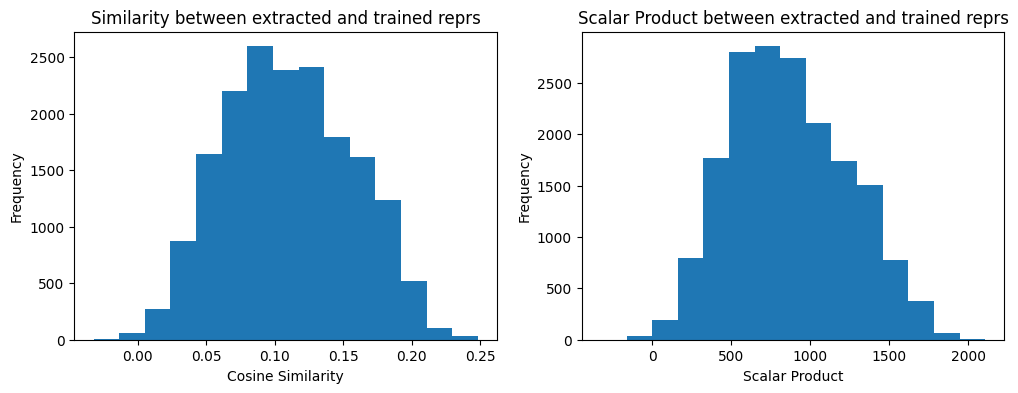

In [150]:
from torch.nn.functional import cosine_similarity

similarities = [
    cosine_similarity(d['representation'], d['trained_rep'], dim=0).item()
    for d in augmented_data
    ]

#compute scalar product between representations
scalar_products = [
    torch.dot(d['representation'], d['trained_rep']).item()
    for d in augmented_data
    ]

random_similarities = [
    cosine_similarity(random_reprs[np.random.randint(len(random_reprs))], 
                      augmented_data[i]['representation'], dim=0).item() 
                      for i in range(len(augmented_data))
                      ]
random_products = [
        torch.dot(random_reprs[np.random.randint(len(random_reprs))], 
                      augmented_data[i]['representation']).item() 
                      for i in range(len(augmented_data))
                      ]
random_random_mean_smilarity = np.mean([
    cosine_similarity(random_reprs[i], random_reprs[j], dim=0).item() 
    for i in range(len(random_reprs) - 1) 
    for j in range(i+1, len(random_reprs))])

print("mean similarity between random representations at layer",layer, ":", random_random_mean_smilarity)
print("mean similarity between learned and extracted representations:", np.mean(similarities))
print("mean similarity between random and extracted representations:", np.mean(random_similarities))

print("mean scalar product between learned and extracted representations:", np.mean(scalar_products))
print("mean scalar product between random and extracted representations:", np.mean(random_products))

#plot similarities distribution and scalar products side by side
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(similarities, bins=15)
axs[0].set_xlabel("Cosine Similarity")
axs[0].set_ylabel("Frequency")
axs[0].set_title("Similarity between extracted and trained reprs")

axs[1].hist(scalar_products, bins=15)
axs[1].set_ylabel("Frequency")
axs[1].set_xlabel("Scalar Product")
axs[1].set_title("Scalar Product between extracted and trained reprs")
plt.show()

Text(0, 0.5, 'Frequency')

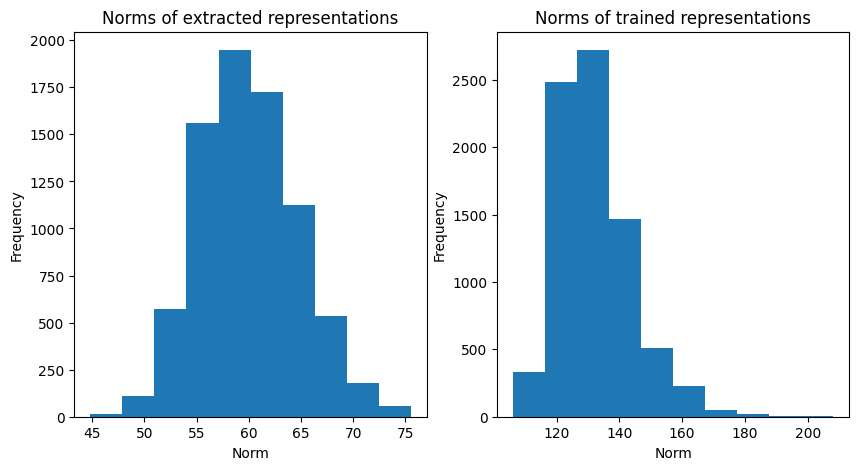

In [149]:
#plot the distribution of norms 
extracted_norms = [torch.norm(augmented_data[i]['representation'], p=2).item() for i in range(len(data))]
trained_norms = [torch.norm(augmented_data[i]['trained_rep'], p=2).item() for i in range(len(data))]

## two subplots for norm distributions
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
bins = 10
axs[0].hist(extracted_norms, bins=bins)
axs[0].set_title("Norms of extracted representations")
axs[0].set_xlabel("Norm")


axs[0].set_ylabel("Frequency")

axs[1].hist(trained_norms, bins=bins)
axs[1].set_title("Norms of trained representations")
axs[1].set_xlabel("Norm")
axs[1].set_ylabel("Frequency")

### Comparing the mean vectors

In [155]:
trained_mean = torch.vstack([d['trained_rep'].view(1,-1) for d in augmented_data]).mean(dim=0)
extracted_mean = torch.vstack([d['representation'].view(1,-1) for d in augmented_data]).mean(dim=0)

print("Mean of trained representations:", trained_mean)
print("Mean of extracted representations:", extracted_mean)
print("Cosine similarity between means:", cosine_similarity(trained_mean, extracted_mean, dim=0).item())
print("Scalar product between means:", torch.dot(trained_mean, extracted_mean).item())

Mean of trained representations: tensor([-0.1741,  1.1987, -0.8401,  ..., -0.4338,  1.7231, -1.1953])
Mean of extracted representations: tensor([ 0.3083, -0.2533,  0.0712,  ..., -0.0247, -0.1935,  0.6004])
Cosine similarity between means: 0.107929527759552
Scalar product between means: 232.71807861328125


## SVD Analysis
on a nos données en colonnes $X = [d_1 | ... | d_n ] \in \mathbb R^{h \times n}$ On écrit la décomposition SVD: $$X = U \Sigma V^T$$ 
alors on écrit les données $X$ dans le référentiel des composantes principales : $$X V = U \Sigma $$

In [ ]:
## perform SVD on the trained representations
trained_representations = torch.vstack([d['trained_rep'].view(1,-1) for d in augmented_data])
#same for extracted representations
extracted_representations = torch.vstack([d['representation'].view(1,-1) for d in augmented_data])
print(trained_representations.shape)
center=False

U, S, Vh = torch.pca_lowrank(trained_representations, q = min(trained_representations.shape[0], 2048), center=center)
# U, S, Vh = torch.linalg.svd(trained_representations, full_matrices=True)

U_e, S_e, Vh_e = torch.pca_lowrank(extracted_representations, q= min(trained_representations.shape[0], 2048), center=center)
# U_e, S_e, Vh_e = torch.linalg.svd(extracted_representations, full_matrices=True)


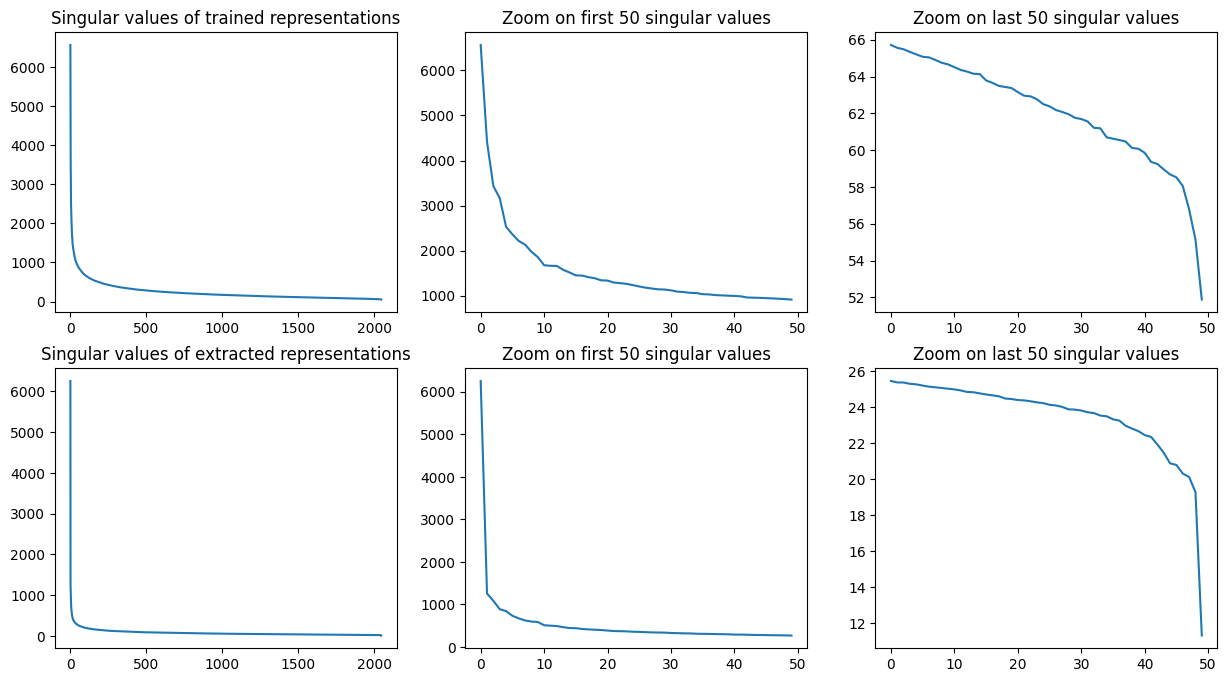

In [162]:
n = 50
fig, axes = plt.subplots(2,3, figsize=(15, 8))
axes[0,0].set_title("Singular values of trained representations")
axes[0,0].plot(S)
axes[0,1].plot(S[:n])
axes[0,1].set_title("Zoom on first 50 singular values")
axes[0,2].plot(S[-n:])
axes[0,2].set_title("Zoom on last 50 singular values")
axes[1,0].plot(S_e)
axes[1,0].set_title("Singular values of extracted representations")
axes[1,1].plot(S_e[:n])
axes[1,1].set_title("Zoom on first 50 singular values")
axes[1,2].plot(S_e[-n:])
axes[1,2].set_title("Zoom on last 50 singular values")

plt.show()


torch.Size([17766, 2048]) torch.Size([2048, 2048])


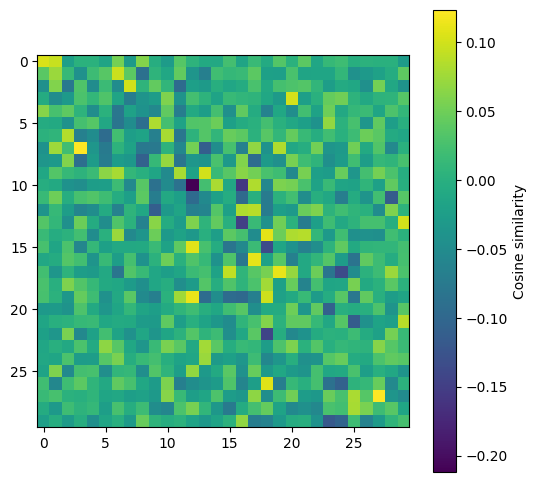

In [164]:
# compute similarity between trained and extracted representations principal components
# U, S, Vh = torch.linalg.svd(trained_representations, full_matrices=False)
# U_e, S_e, Vh_e = torch.linalg.svd(extracted_representations, full_matrices=False)
print(U.shape, Vh.shape)
# sim = cosine_similarity(U, U_e, dim=0)
N = U.shape[1]
k = 30
# similarities between principal components pairs
sims = torch.zeros((k,k))
for i in range(k):
    for j in range(k):
        sims[i,j] = cosine_similarity(Vh[:,i], Vh_e[:,j], dim=0).item()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
# ax.imshow(sims)
# ax.set_title("Cosine similarity between trained and extracted representations principal components")
#colorbar
cbar = plt.colorbar(ax.imshow(sims), ax=ax)
cbar.set_label("Cosine similarity")
plt.show()

In [172]:
#compute distribution of principal components features in data and extracted data

k = 30
V = Vh[:,:k] # trained representations principal components

# project representations on principal components
trained_features =  trained_representations @ V
extracted_features = extracted_representations @ V
random_features = torch.vstack([random_reprs[i].view(1,-1) for i in range(len(random_reprs))]) @ V 

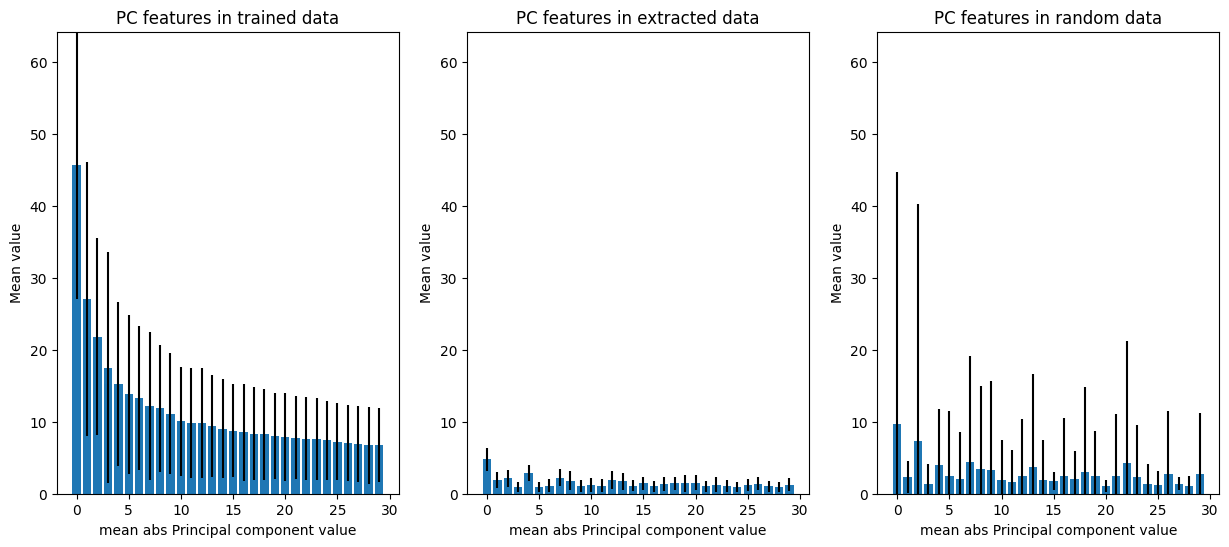

In [173]:
y_min = 0
y_max = 0
#plot distribution of principal components features
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
abs_train = torch.abs(trained_features)
means = abs_train.mean(dim=0)
stds = abs_train.std(dim=0)

y_max = max(y_max, max(means+stds))
axs[0].bar(range(k), means, yerr=stds)
axs[0].set_title("PC features in trained data")
axs[0].set_xlabel("mean abs Principal component value")
axs[0].set_ylabel("Mean value")

abs_extracted = torch.abs(extracted_features)
means = abs_extracted.mean(dim=0)
stds = abs_extracted.std(dim=0)
y_max = max(y_max, max(means+stds))
axs[1].bar(range(k), means, yerr=stds)
axs[1].set_title("PC features in extracted data")
axs[1].set_xlabel("mean abs Principal component value")
axs[1].set_ylabel("Mean value")

abs_random = torch.abs(random_features)
means = abs_random.mean(dim=0)
stds = abs_random.std(dim=0)
y_max = max(y_max, max(means+stds))
axs[2].bar(range(k), means, yerr=stds)
axs[2].set_title("PC features in random data")
axs[2].set_xlabel("mean abs Principal component value")
axs[2].set_ylabel("Mean value")

axs[0].set_ylim(y_min, y_max)
axs[1].set_ylim(y_min, y_max)
axs[2].set_ylim(y_min, y_max)

plt.show()

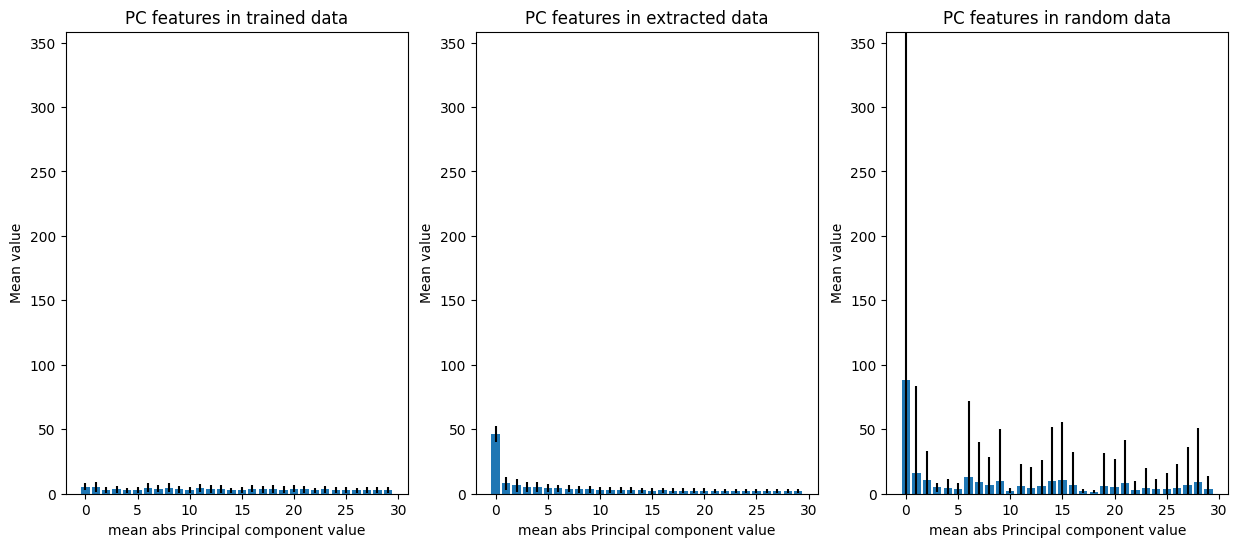

In [174]:
V = Vh_e[:,:k] # extracted representations principal components

# project representations on principal components
trained_features =  trained_representations @ V
extracted_features = extracted_representations @ V
random_features = torch.vstack([random_reprs[i].view(1,-1) for i in range(len(random_reprs))]) @ V 


y_min = 0
y_max = 0
#plot distribution of principal components features
fig, axs = plt.subplots(1, 3, figsize=(15, 6))
abs_train = torch.abs(trained_features)
means = abs_train.mean(dim=0)
stds = abs_train.std(dim=0)

y_max = max(y_max, max(means+stds))
axs[0].bar(range(k), means, yerr=stds)
axs[0].set_title("PC features in trained data")
axs[0].set_xlabel("mean abs Principal component value")
axs[0].set_ylabel("Mean value")

abs_extracted = torch.abs(extracted_features)
means = abs_extracted.mean(dim=0)
stds = abs_extracted.std(dim=0)
y_max = max(y_max, max(means+stds))
axs[1].bar(range(k), means, yerr=stds)
axs[1].set_title("PC features in extracted data")
axs[1].set_xlabel("mean abs Principal component value")
axs[1].set_ylabel("Mean value")

abs_random = torch.abs(random_features)
means = abs_random.mean(dim=0)
stds = abs_random.std(dim=0)
y_max = max(y_max, max(means+stds))
axs[2].bar(range(k), means, yerr=stds)
axs[2].set_title("PC features in random data")
axs[2].set_xlabel("mean abs Principal component value")
axs[2].set_ylabel("Mean value")

axs[0].set_ylim(y_min, y_max)
axs[1].set_ylim(y_min, y_max)
axs[2].set_ylim(y_min, y_max)

plt.show()

# Fit a linear model to predict the trained representations from the extracted

In [175]:
#split data in train and test
from sklearn.model_selection import train_test_split
X = torch.vstack([d['trained_rep'].view(1,-1) for d in augmented_data])
y = torch.vstack([d['representation'].view(1,-1) for d in augmented_data])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Torch Optim

In [194]:
P = torch.eye(trained_representations.shape[1], dtype=dtype, device="cuda")
P.requires_grad = True
P.shape

history = []

In [214]:

epochs = 100
batch_size = 500

# optimizer
optim = torch.optim.Adam([P], lr=1e-4)
# optim = torch.optim.SGD([P], lr=1e-5)

# criterion = torch.nn.MSELoss()
criterion = torch.nn.CosineEmbeddingLoss()

#dataloader from datasets
train_loader = DataLoader(augmented_data, batch_size=batch_size, shuffle=True)
log_every = 10

for epoch in range(epochs):
    for batch in train_loader:
        # Zero the gradients
        optim.zero_grad()
        
        extracted_reps = batch['representation'].cuda()
        trained_reps = batch['trained_rep'].cuda()
        y = torch.ones(trained_reps.shape[0], device="cuda")
        # print(extracted_reps.shape, trained_reps.shape)
        # Project augmented_batch representations using matrix P
        projected = extracted_reps @ P
        
        # Compute the loss between projected_batch and trained_reps
        loss = criterion(projected, trained_reps, y)
        
        # Backpropagation
        loss.backward()
        
        # Update the matrix P
        optim.step()
        
        # Log the loss
        history.append(
            {
                "epoch": epoch,
                "batch": len(history),
                "loss": loss.item(),
            }
        )
    if epoch % log_every == 0:
        print(f"Epoch: {epoch+1}, Batch: {len(history)}, Loss: {loss.item()}")



Epoch: 1, Batch: 217413, Loss: 0.20800107717514038
Epoch: 11, Batch: 217773, Loss: 0.18278418481349945
Epoch: 21, Batch: 218133, Loss: 0.18931114673614502
Epoch: 31, Batch: 218493, Loss: 0.20917819440364838
Epoch: 41, Batch: 218853, Loss: 0.20289704203605652
Epoch: 51, Batch: 219213, Loss: 0.20561498403549194
Epoch: 61, Batch: 219573, Loss: 0.1957188993692398
Epoch: 71, Batch: 219933, Loss: 0.1766279637813568
Epoch: 81, Batch: 220293, Loss: 0.19889475405216217
Epoch: 91, Batch: 220653, Loss: 0.19704149663448334


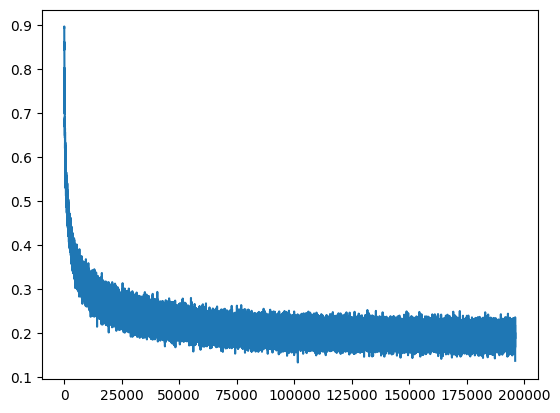

In [211]:
#plot loss
plt.plot([h["batch"] for h in history], [h["loss"] for h in history])

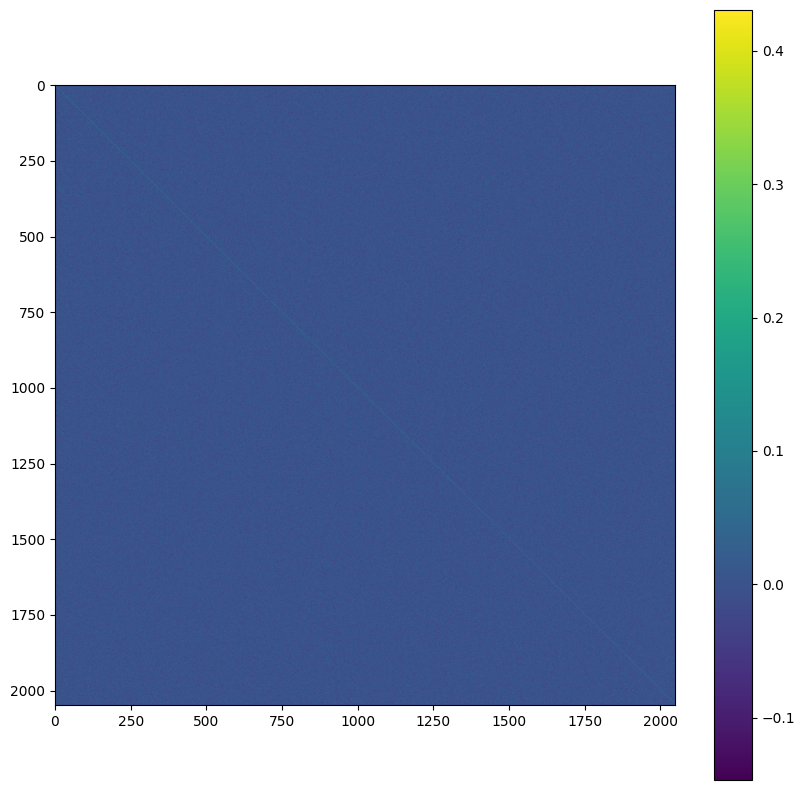

In [216]:
# plot P matrix
plt.figure(figsize=(10,10))
plt.imshow(P.detach().cpu().numpy())
plt.colorbar()

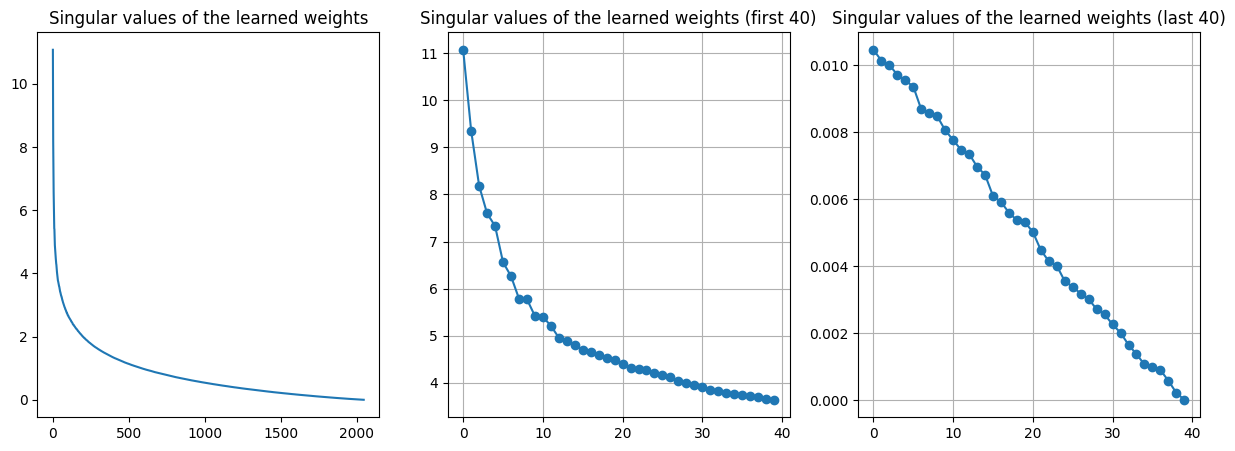

In [219]:
#svd for the learned weights
with torch.no_grad():
    U, S, Vh = torch.linalg.svd(
        P,
        full_matrices=True)
N = 40
# plot of the singular values and a zoom on the first N
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].plot(S.detach().cpu().numpy())
ax[0].set_title("Singular values of the learned weights")
ax[1].plot(S.detach().cpu().numpy()[:N], 'o-')
ax[1].set_title(f"Singular values of the learned weights (first {N})")
ax[1].grid()
ax[2].plot(S.detach().cpu().numpy()[-N:], 'o-')
ax[2].set_title(f"Singular values of the learned weights (last {N})")
ax[2].grid()
plt.show()

### Sklearn

In [179]:
from sklearn.linear_model import LinearRegression
import numpy as np

print(X_train.shape, y_train.shape)
# Create a linear regression model
LinReg = LinearRegression()

# Fit the LinReg to the data
LinReg.fit(X_train, y_train)

cleaned_reps = LinReg.predict(X_test)

P = torch.tensor(LinReg.coef_)
# Print the coefficients and intercept
print("Coefficients:", LinReg.coef_.shape)
print("Intercept:", LinReg.intercept_)
print("Score:", LinReg.score(X_train, y_train))
#print MSE loss
print("Mean Squared Error on Test:", np.mean((cleaned_reps - y_test.numpy()) ** 2))

torch.Size([14212, 2048]) torch.Size([14212, 2048])
Coefficients: (2048, 2048)
Intercept: [ 0.38955584 -0.1342928  -0.02818478 ...  0.12319311 -0.09772841
  0.45180178]
Score: 0.5725001932640013
Mean Squared Error on Test: 0.46685722


# Test projection on test data

In [200]:
Limit = 3000

test_dataset.data = test_dataset[:Limit]
print("test length:", len(test_dataset))
test_dataset.augment_with_repr(model, layer=layer, batch_size=10, method='in_context')
test_dataset[0]

test length: 1000


100%|█████████████████████████████████████████████████████████████████████████████| 100/100 [00:04<00:00, 22.06it/s]


{'entity': 'JAPAN',
 'text': 'SOCCER - JAPAN GET LUCKY WIN, CHINA IN SURPRISE DEFEAT.',
 'id': 0,
 'representation': tensor([ 1.3040,  1.2369,  0.2398,  ..., -0.9309, -0.6852, -1.3331]),
 'inferred': 'JAPAN'}

In [201]:
#clean inferred 
for d in test_dataset:
    d.pop("inferred", None)
#baseline score
print("Computing score with raw Extracted representations:")
print(compute_metrics(model=model, 
                      TaskVec=TaskVec, 
                      test_dataset=test_dataset,
                      with_context=with_context,
                      ))


Computing score with raw Extracted representations:


100%|██████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1192919.23it/s]


{'Partial Match': 0.563, 'Exact Match': 0.476, 'Chr-F': 47.873691352543105, 'Version': 1.2}


In [217]:
import copy
# test_dataset = augmented_data
#build new dataset with cleaned representations:
cleaned_test_dataset = copy.deepcopy(test_dataset)
with torch.no_grad():
    for item in cleaned_test_dataset:
        # item["representation"] = torch.tensor(LinReg.predict(item["representation"].view(1,-1)).squeeze())
        item["representation"] = (item["representation"].cuda() @ P).detach().cpu()

#check difference between raw and cleaned representations
print(cleaned_test_dataset[0]["representation"])
print(test_dataset[0]["representation"])

# print("Computing score with cleaned? representations:")
print(compute_metrics(model=model, 
                      TaskVec=TaskVec, 
                      test_dataset=cleaned_test_dataset,
                      with_context=with_context,
                      ))


tensor([-1.2612,  0.8946, -0.2477,  ...,  0.8734,  0.4419, -1.4213])
tensor([ 1.3040,  1.2369,  0.2398,  ..., -0.9309, -0.6852, -1.3331])


100%|██████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1163791.34it/s]


{'Partial Match': 0.415, 'Exact Match': 0.366, 'Chr-F': 33.629841221512045, 'Version': 1.2}


In [183]:
rep = test_dataset[0]["representation"].view(-1,1)
print(torch.tensor(LinReg.predict(rep.T)))
print(P.T @ rep)

tensor([[-0.2930,  0.2529,  0.2929,  ...,  0.6192,  0.9076,  0.4239]])
tensor([[ 2.7057],
        [ 3.5473],
        [-1.7712],
        ...,
        [-1.1700],
        [ 2.2677],
        [ 2.1784]])


In [221]:
for d in cleaned_test_dataset[:100]:
    # print(d["text"])
    success = d["entity"].strip() == d["inferred"].strip()
    print(f"target: '{d['entity'].strip()}' |   _ > '{d['inferred']}'\n", success)
    if not success:
        print(d['text'])

target: 'JAPAN' |   _ > 'ANA'
 False
SOCCER - JAPAN GET LUCKY WIN, CHINA IN SURPRISE DEFEAT.
target: 'CHINA' |   _ > 'CHINA'
 True
target: 'AL-AIN' |   _ > 'AAD'
 False
AL-AIN, United Arab Emirates 1996-12-06
target: 'United Arab Emirates' |   _ > 'Hong Kong'
 False
AL-AIN, United Arab Emirates 1996-12-06
target: 'Japan' |   _ > 'Japan'
 True
target: 'Asian Cup' |   _ > 'World Cup'
 False
Japan began the defence of their Asian Cup title with a lucky 2-1 win against Syria in a Group C championship match on Friday.
target: 'Syria' |   _ > 'Syria'
 True
target: 'China' |   _ > 'China'
 True
target: 'Uzbekistan' |   _ > 'Uzbekistan'
 True
target: 'China' |   _ > 'China'
 True
target: 'Uzbek' |   _ > 'Uzbek'
 True
target: 'Igor Shkvyrin' |   _ > 'J. P. Hoever'
 False
China controlled most of the match and saw several chances missed until the 78th minute when Uzbek striker Igor Shkvyrin took advantage of a misdirected defensive header to lob the ball over the advancing Chinese keeper and int

# Conclusion

- We are able to "compress" almost any sequence of tokens inside a representation and make the model reconstruct it.
- The obtained representations don't seem to live in the same subspace where internal representations live, even if we have some similarities.
- The method is flawed anyways, optimizing an MSE is not a good idea ! **what matters are directions and not distances.**